In [1]:
import os, sys, time, re, pickle, importlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import simbench as sb
from functools import lru_cache
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from tqdm.auto import tqdm

# Get notebook directory and parent (project root)
notebook_dir = Path(os.getcwd())
project_dir = notebook_dir.parent

# Add project directory to Python path
sys.path.append(str(project_dir))

from src.analyze_results import prepare_results
from src.analyze_results import analyze_results_cost

c:\Users\55485\AppData\Local\anaconda3\envs\PhD_energyFlow_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [3]:
importlib.reload(prepare_results)
importlib.reload(analyze_results_cost)

<module 'src.analyze_results.analyze_results_cost' from 'c:\\Users\\55485\\OneDrive - Bain\\Documents\\02 - PhD\\01 - Forschung\\02 - Paper 2\\Code\\BESS Optimization\\v5\\src\\analyze_results\\analyze_results_cost.py'>

In [4]:
# Set the maximum number of rows to display in total
pd.set_option('display.max_rows', 300)

# Set the minimum number of rows to display before truncating
pd.set_option('display.min_rows', 200)

# set the max columns to none
pd.set_option('display.max_columns', None)

In [5]:
# Define necessary OPEX parameters
maintenance_percentage_trafo = 0.02 # Source: Verteilnetzstudie Hessen
maintenance_percentage_line = 0.01  # Source: Verteilnetzstudie Hessen

equity_rate = 0.0769  # Source: Eigenkapitalzinssatz für Neuinvestitionen inkl. Gewerbesteuer, BNetzA
equity_percentage = 0.4  # Source: Pauschale Eigenkapitalquote,BNetzA
debt_rate = 0.0171  # Source: Kalkulatorischer Fremdkapitalzinssatz 4. Periode, BNetzA

current_HP_percentage = 5.7 # Source: bdew Report "Wie heizt Deutschland"

hp_tariff_discount = 0.6 # $14a EnWG

sales_tax = 0.19

payback_period_line = 40  # Source: BNetzA, in years
payback_period_trafo = 30  # Source: BNetzA, in years
discount_rate = (equity_percentage * equity_rate) + ((1 - equity_percentage) * debt_rate) # WACC calculation

In [6]:
importlib.reload(prepare_results)

<module 'src.analyze_results.prepare_results' from 'c:\\Users\\55485\\OneDrive - Bain\\Documents\\02 - PhD\\01 - Forschung\\02 - Paper 2\\Code\\BESS Optimization\\v5\\src\\analyze_results\\prepare_results.py'>

In [7]:
results = prepare_results._load_all_results("HV")
results_df = prepare_results._create_results_df(results)
results_df = prepare_results._create_cumsum(results_df)

# Define scenario space
scenario_space = [
    {"name": "!: Base", "hp": 0,  "ev": 0,  "pv": 0},
    {"name": "0: 2024", "hp": 4,  "ev": 3,  "pv": 14},
    {"name": "1: 2030", "hp": 30, "ev": 35, "pv": 27},
    {"name": "2: 2035", "hp": 42, "ev": 55, "pv": 34},
    {"name": "3: 2040", "hp": 52, "ev": 75, "pv": 49},
    {"name": "4: 2045", "hp": 72, "ev": 95, "pv": 61},
    {"name": "5: Max stress", "hp": 100, "ev": 100, "pv": 100},
]

# Assign scenario labels
results_df = prepare_results._assign_scenarios(results_df, scenario_space)

# Get static loads
static_loads = prepare_results._get_static_loads()
results_df = results_df.merge(static_loads[["grid", "total_static_load"]], on="grid", how="left")
results_df["total_static_load"] = results_df["total_static_load"]*1000
results_df["base_load_hh_only"] = results_df["base_load"] - results_df["total_static_load"]
results_df["scenario_load_hh_only"] = results_df["scenario_load"] - results_df["total_static_load"]

In [8]:
# Filter data for HV-mixed and HV-urban grids
hv_mixed_data = results_df[results_df['grid'] == 'HV-mixed'].copy()
hv_urban_data = results_df[results_df['grid'] == 'HV-urban'].copy()

# Calculate reinforcement cost per household
hv_mixed_data['cost_per_household'] = hv_mixed_data['total_reinforcement_cost'] / hv_mixed_data['total_households']
hv_urban_data['cost_per_household'] = hv_urban_data['total_reinforcement_cost'] / hv_urban_data['total_households']

# Calculate mean and standard deviation at each adoption level
hv_mixed_summary = hv_mixed_data.groupby(['tariff', 'scenario']).agg({
    'cost_per_household': ['mean', 'std'],
    'scenario_load': 'mean'
}).reset_index()
# Flatten MultiIndex columns for hv_mixed_summary
hv_mixed_summary.columns = ['tariff', 'scenario', 'mean', 'std', 'scenario_load']

hv_urban_summary = hv_urban_data.groupby(['tariff', 'scenario']).agg({
    'cost_per_household': ['mean', 'std'],
    'scenario_load': 'mean'
}).reset_index()
# Flatten MultiIndex columns for hv_urban_summary
hv_urban_summary.columns = ['tariff', 'scenario', 'mean', 'std', 'scenario_load']

In [9]:
project_dir = Path(project_dir)  # ensure Path
LV_dir = project_dir / "data" / "scenario_files" / "LV"
results_HV = analyze_results_cost._load_all_results("HV")
results_MV = analyze_results_cost._load_all_results("MV")

# ---------- Build lightweight tasks serially (touch heavy dicts only once) ----------
tasks = []
for i in results_HV.keys():
    for j in results_HV[i].keys():
        for k in results_HV[i][j].keys():
            hv_df = results_HV[i][j][k]["VOL"]["hh_attribution"]
            hv_counts = (
                hv_df.value_counts(["grid", "seed"])
                    .rename("n").reset_index()
            )
            parts = []
            for grid_mv, seed_mv, n_mv in hv_counts.itertuples(index=False):
                mv_df = results_MV[grid_mv][seed_mv][k]["VOL"]["hh_attribution"]
                c = (mv_df.value_counts(["grid", "seed"])
                        .rename("n").reset_index())
                c["n"] = c["n"] * int(n_mv)
                parts.append(c)

            if not parts:
                continue

            mv_counts_df = (pd.concat(parts, ignore_index=True)
                            .groupby(["grid", "seed"], as_index=False)["n"].sum())
            mv_counts_list = list(mv_counts_df.itertuples(index=False, name=None))  # (grid, seed, n)
            tasks.append({"i": i, "j": j, "k": k, "mv_counts": mv_counts_list, "lv_dir_str": str(LV_dir)})

print(f"Prepared {len(tasks)} (grid, seed, scenario) tasks.")

Prepared 140 (grid, seed, scenario) tasks.


In [10]:
# ---------- Run parallel with visible progress ----------
max_workers = max(1, (os.cpu_count() or 2) - 2)
print(f"Starting parallel LV aggregation with {max_workers} workers...\n")

t0 = time.time()
with threadpool_limits(limits=1):
    results = Parallel(
        n_jobs=max_workers,
        backend="loky",
        prefer="processes",
        batch_size=1,
        verbose=5,
    )(
        delayed(prepare_results._worker_lv_verbose)(t)
        for t in tqdm(tasks, desc="LV aggregation", ncols=100)
    )

elapsed = time.time() - t0
print(f"\nAll workers finished in {elapsed/60:.2f} minutes.")

# ---------- Merge ----------
# Split the tuple results into two lists, skipping Nones/empties
hh_parts = [r[0] for r in results if r is not None and isinstance(r, tuple) and r[0] is not None and len(r[0])]
pt_parts = [r[1] for r in results if r is not None and isinstance(r, tuple) and r[1] is not None and len(r[1])]

# Define empty fallbacks with expected schemas
hh_empty_cols = [
    "grid","seed","tariff","HP_percentage","EV_percentage","PV_percentage",
    "has_HP","has_EV","has_PV_BESS","n_households","max_deployed_discharge_kW",
    "import_kWh", "window_peak_kW", "import_in_cpp_events_kWh"
]
pt_empty_cols = [
    "grid","seed","tariff","HP_percentage","EV_percentage","PV_percentage",
    "top_time_index","has_HP","has_EV","has_PV_BESS",
    "n_households","hh_hp_ev_kW","pv_kW","bess_kW","import_kW"
]

hh_attribution_main = (pd.concat(hh_parts, ignore_index=True)
                       if hh_parts else pd.DataFrame(columns=hh_empty_cols))
peak_times_main = (pd.concat(pt_parts, ignore_index=True)
                   if pt_parts else pd.DataFrame(columns=pt_empty_cols))


Starting parallel LV aggregation with 12 workers...



LV aggregation: 100%|█████████████████████████████████████████████| 140/140 [06:36<00:00,  2.83s/it]
[Parallel(n_jobs=12)]: Done 140 out of 140 | elapsed:  7.7min finished



All workers finished in 7.74 minutes.


In [11]:
# If you still want scenario labels added, apply your helper to BOTH
hh_attribution_main = analyze_results_cost._assign_scenarios(hh_attribution_main, scenario_space)
peak_times_main = analyze_results_cost._assign_scenarios(peak_times_main, scenario_space)

In [12]:
hh_attribution_main.head()

,grid,seed,tariff,HP_percentage,EV_percentage,PV_percentage,has_HP,has_EV,has_PV_BESS,n_households,max_deployed_discharge_kW,import_kWh,window_peak_kW,import_in_cpp_events_kWh,scenario
0,HV-mixed,41,VOL,0,0,0,False,False,False,303899,0.0,808615296.0,1359597.750,0.0,"!: Base (0% HP, 0% EV, 0% PV/BESS)"
1,HV-mixed,41,IPP,0,0,0,False,False,False,303899,0.0,808615296.0,1359597.750,0.0,"!: Base (0% HP, 0% EV, 0% PV/BESS)"
2,HV-mixed,41,CPP,0,0,0,False,False,False,303899,0.0,808615296.0,1359597.750,4759552.0,"!: Base (0% HP, 0% EV, 0% PV/BESS)"
3,HV-mixed,41,MAX,0,0,0,False,False,False,303899,0.0,808615296.0,1359597.750,0.0,"!: Base (0% HP, 0% EV, 0% PV/BESS)"
4,HV-mixed,41,VOL,4,3,14,False,False,False,246127,0.0,654143360.0,1100017.875,0.0,"0: 2024 (4% HP, 3% EV, 14% PV/BESS)"


# 0: Check statistical significance

In [13]:
# Set confidence level and Z-score for alpha = 0.05
confidence_level = 0.95
z_score = stats.norm.ppf((1 + confidence_level) / 2)

# Define acceptable margin of error as a percentage of the mean (e.g., 5%)
margin_error_percentage = 0.05

# Calculate confidence interval and minimum sample size
def significance_check_and_sample_size(summary_df, data_df):
    # Determine the number of unique runs based on the unique values in the 'random_seed' column
    n = data_df['seed'].nunique()

    significance_results = []

    for _, row in summary_df.iterrows():
        tariff = row['tariff']
        scenario = row['scenario']
        mean_cost = row['mean']
        std_dev = row['std']

        # Calculate current margin of error
        margin_of_error = z_score * (std_dev / np.sqrt(n))

        # Check if the current runs are significant
        is_significant = margin_of_error <= (margin_error_percentage * mean_cost)

        # Calculate required sample size for desired margin of error
        desired_margin_of_error = margin_error_percentage * mean_cost
        required_sample_size = (z_score * std_dev / desired_margin_of_error) ** 2

        # Store results
        significance_results.append({
            'tariff': tariff,
            'scenario': scenario,
            'mean_cost': mean_cost,
            'std_dev': std_dev,
            'current_margin_of_error': margin_of_error,
            'is_significant': is_significant,
            'required_sample_size': np.ceil(required_sample_size)  # Round up to the nearest whole number
        })

    # Convert to DataFrame for easy viewing
    return pd.DataFrame(significance_results)

# Run significance check and sample size calculation for HV-mixed and HV-urban summaries
hv_mixed_significance = significance_check_and_sample_size(hv_mixed_summary, hv_mixed_data)
hv_urban_significance = significance_check_and_sample_size(hv_urban_summary, hv_urban_data)

In [14]:
# Display the results
print("Distribution Grid - rural: Significance and Required Sample Sizes:")
hv_mixed_significance[['scenario', 'tariff', 'mean_cost', 'current_margin_of_error', 'is_significant', 'required_sample_size']]

Distribution Grid - rural: Significance and Required Sample Sizes:


,scenario,tariff,mean_cost,current_margin_of_error,is_significant,required_sample_size
0,"!: Base (0% HP, 0% EV, 0% PV/BESS)",CPP,190.266914,0.707141,True,1.0
1,"0: 2024 (4% HP, 3% EV, 14% PV/BESS)",CPP,190.977718,0.666782,True,1.0
2,"1: 2030 (30% HP, 35% EV, 27% PV/BESS)",CPP,713.097786,6.365576,True,1.0
3,"2: 2035 (42% HP, 55% EV, 34% PV/BESS)",CPP,1180.240337,13.024796,True,1.0
4,"3: 2040 (52% HP, 75% EV, 49% PV/BESS)",CPP,1584.605868,16.249739,True,1.0
5,"4: 2045 (72% HP, 95% EV, 61% PV/BESS)",CPP,2087.951114,16.981902,True,1.0
6,"5: Max stress (100% HP, 100% EV, 100% PV/BESS)",CPP,2920.243845,24.993289,True,1.0
7,"!: Base (0% HP, 0% EV, 0% PV/BESS)",IPP,190.266914,0.707141,True,1.0
8,"0: 2024 (4% HP, 3% EV, 14% PV/BESS)",IPP,191.202956,0.691832,True,1.0
9,"1: 2030 (30% HP, 35% EV, 27% PV/BESS)",IPP,735.854203,5.845024,True,1.0


In [15]:
print("\nDistribution Grid - urban: Significance and Required Sample Sizes:")
hv_urban_significance[['scenario', 'tariff', 'mean_cost', 'current_margin_of_error', 'is_significant', 'required_sample_size']]


Distribution Grid - urban: Significance and Required Sample Sizes:


,scenario,tariff,mean_cost,current_margin_of_error,is_significant,required_sample_size
0,"!: Base (0% HP, 0% EV, 0% PV/BESS)",CPP,250.556978,4.319699,True,2.0
1,"0: 2024 (4% HP, 3% EV, 14% PV/BESS)",CPP,251.290680,4.257801,True,2.0
2,"1: 2030 (30% HP, 35% EV, 27% PV/BESS)",CPP,1079.997870,9.579943,True,1.0
3,"2: 2035 (42% HP, 55% EV, 34% PV/BESS)",CPP,1543.052230,10.328619,True,1.0
4,"3: 2040 (52% HP, 75% EV, 49% PV/BESS)",CPP,2016.496845,7.805205,True,1.0
5,"4: 2045 (72% HP, 95% EV, 61% PV/BESS)",CPP,2694.687928,20.676736,True,1.0
6,"5: Max stress (100% HP, 100% EV, 100% PV/BESS)",CPP,3579.728737,21.848273,True,1.0
7,"!: Base (0% HP, 0% EV, 0% PV/BESS)",IPP,250.556978,4.319699,True,2.0
8,"0: 2024 (4% HP, 3% EV, 14% PV/BESS)",IPP,251.597731,4.222164,True,2.0
9,"1: 2030 (30% HP, 35% EV, 27% PV/BESS)",IPP,1110.091711,5.937566,True,1.0


# Peak load

C:\Users\55485\AppData\Local\Temp\ipykernel_14400\1180523365.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wavg_multi(g))


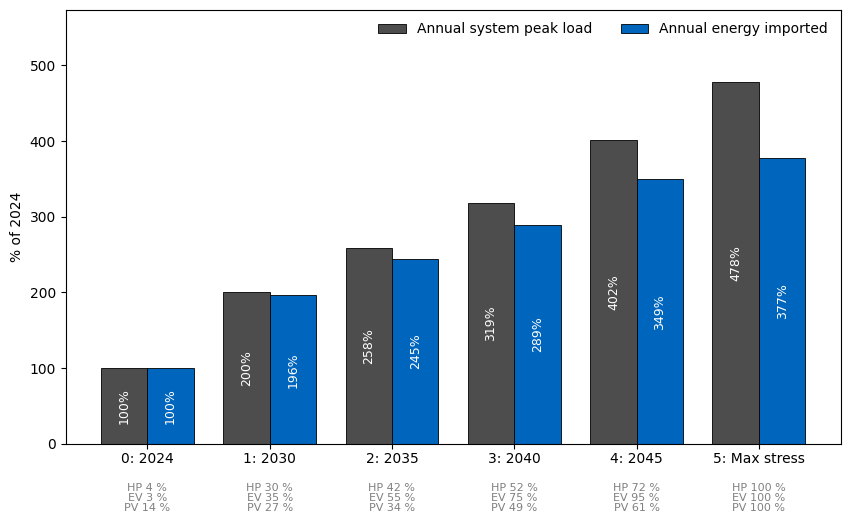

In [16]:
# --- Relative peak chart for VOL baseline (Today = 100%, Base removed) ---
# ----------------- helpers -----------------
def short_label(s: str, mode: str = "prefix_plus_year") -> str:
    """Format scenario labels, keep numeric prefix, tidy common names."""
    m = re.match(r'^\s*(\d+):\s*([^(]+)', str(s))
    if not m:
        return str(s).strip()
    idx, name = m.group(1), m.group(2).strip()
    lname = name.lower()
    if lname.startswith("base"):
        name = "Base"
    elif lname.startswith("max stress"):
        name = "Max stress"
    return name if mode == "year_only" else f"{idx}: {name}"

def _numkey(s):
    m = re.match(r"^\s*(\d+)", str(s))
    return int(m.group(1)) if m else 10**9

# 1) Filter VOL and average across seeds
df = results_df[results_df["tariff"] == "VOL"].copy()
grp_cols = ["scenario", "grid", "tariff"]
avg = df.groupby(grp_cols, as_index=False)[["scenario_load_hh_only"]].mean()

df_2 = hh_attribution_main[hh_attribution_main["tariff"]=="VOL"].copy()
avg_2 = df_2.groupby(["scenario", "grid", "tariff", "has_HP", "has_EV", "has_PV_BESS"]).agg({
    'import_kWh': 'mean'}).reset_index().groupby(["scenario", "grid", "tariff"]).agg({
    'import_kWh': 'sum'}).reset_index()

avg = avg.merge(avg_2, on=grp_cols, how="left")

# 2) Optional household-weighted system aggregation
if "total_households" in df.columns:
    hh = df.groupby(grp_cols, as_index=False)["total_households"].mean()
    avg = avg.merge(hh, on=grp_cols, how="left")

    def wavg_multi(block, vals=("scenario_load_hh_only", "import_kWh"), w="total_households"):
        wv = block[w].to_numpy()
        denom = np.nansum(wv)
        out = {}
        for col in vals:
            v = block[col].to_numpy()
            out[col] = np.nan if denom == 0 else np.nansum(v * wv) / denom
        return pd.Series(out)

    sys = (
        avg.groupby(["scenario", "tariff"])
           .apply(lambda g: wavg_multi(g))
           .reset_index()
    )
else:
    sys = (
        avg.groupby(["scenario", "tariff"], as_index=False)
           [["scenario_load_hh_only", "import_kWh"]].mean()
    )

# 3) Sort scenarios by numeric prefix & format labels
sys = sys.sort_values("scenario", key=lambda s: s.map(_numkey)).reset_index(drop=True)
labels = [short_label(s, "prefix_plus_year") for s in sys["scenario"]]
vals = sys[["scenario_load_hh_only", "import_kWh"]].to_numpy(dtype=float)

# 4) Normalize to "Today"
#    (rename any "...: 2024" to "...: Today" in labels first)
# labels = [lbl.replace(": 2024", ": Today") for lbl in labels]
today_mask = [("2024" in lbl.lower()) for lbl in labels]
if not any(today_mask):
    raise ValueError("No 'Today' scenario found (e.g., label contains ': Today'). Adjust naming or mapping.")
today_idx = np.where(today_mask)[0][0]
norm_all = (vals / vals[today_idx]) * 100.0

# 5) Remove Base scenario & build clean lists
keep_mask = [not ("base" in lbl.lower()) for lbl in labels]
labels_clean = np.array(labels)[keep_mask].tolist()
norm_clean = norm_all[keep_mask]

# 6) Keys for adoption labels (right side of the colon)
scenario_names = labels_clean                              # full labels for the top line
scenario_keys = [lbl.split(":")[-1].strip() for lbl in labels_clean]  # e.g., 'Today', '2030', 'Max stress'

# ----------------- adoption labels (EDIT with your actual values) -----------------
adoption_labels = {
    "2024":      "HP 4 %\nEV 3 %\nPV 14 %",
    "2030":       "HP 30 %\nEV 35 %\nPV 27 %",
    "2035":       "HP 42 %\nEV 55 %\nPV 34 %",
    "2040":       "HP 52 %\nEV 75 %\nPV 49 %",
    "2045":       "HP 72 %\nEV 95 %\nPV 61 %",
    "Max stress": "HP 100 %\nEV 100 %\nPV 100 %",
}
adopt_text = [adoption_labels.get(k, "") for k in scenario_keys]

# --- Grouped bar plot for both metrics ---
fig, ax = plt.subplots(figsize=(max(10, len(labels_clean) * 1.2), 7))
x = np.arange(len(labels_clean))

# norm_clean is (n_scenarios, 2): [:,0]=scenario_load_hh_only, [:,1]=import_kWh
norm_clean = norm_all[keep_mask]

metric_names = ["Annual system peak load", "Annual energy imported"]
nseries = norm_clean.shape[1]
width = 0.38  # bar width
offsets = [(i - (nseries - 1)/2) * width for i in range(nseries)]

bars = []

colors = ["#4D4D4D", "#0065BD"]  # dark gray + blue

for j in range(nseries):
    pos = x + offsets[j]
    bj = ax.bar(
        pos,
        norm_clean[:, j],
        width,
        color=colors[j],
        edgecolor="black",
        linewidth=0.6,
        label=metric_names[j],
    )
    bars.append(bj)
    # % labels
    for xi, v in zip(pos, norm_clean[:, j]):
        if np.isnan(v):
            continue
        ax.text(
            xi, v * 0.5, f"{v:.0f}%",  # position: halfway up the bar
            ha="center", va="center",
            rotation=90, fontsize=9,
            color="white" if v > 40 else "black",  # automatic contrast
        )

# Ticks show the scenario group centers
ax.set_xticks(x)
ax.set_xticklabels(labels_clean, fontsize=10)

# Y-limits based on both series
ymax = np.nanmax(norm_clean) if np.isfinite(np.nanmax(norm_clean)) else 100
ax.set_ylim(0, ymax * 1.2)

# Pull scenario names closer to axis
ax.tick_params(axis='x', pad=2)

# Adoption labels centered under each scenario group
for xi, txt in zip(x, adopt_text):
    ax.text(
        xi, -0.09, txt,
        transform=ax.get_xaxis_transform(),
        ha="center", va="top",
        fontsize=8, color="gray",
        linespacing=1.0
    )

# Legend + labels
ax.set_ylabel("% of 2024")
ax.legend(ncol=2, frameon=False)
plt.subplots_adjust(bottom=0.26)

C:\Users\55485\AppData\Local\Temp\ipykernel_14400\3482709477.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wavg(g))


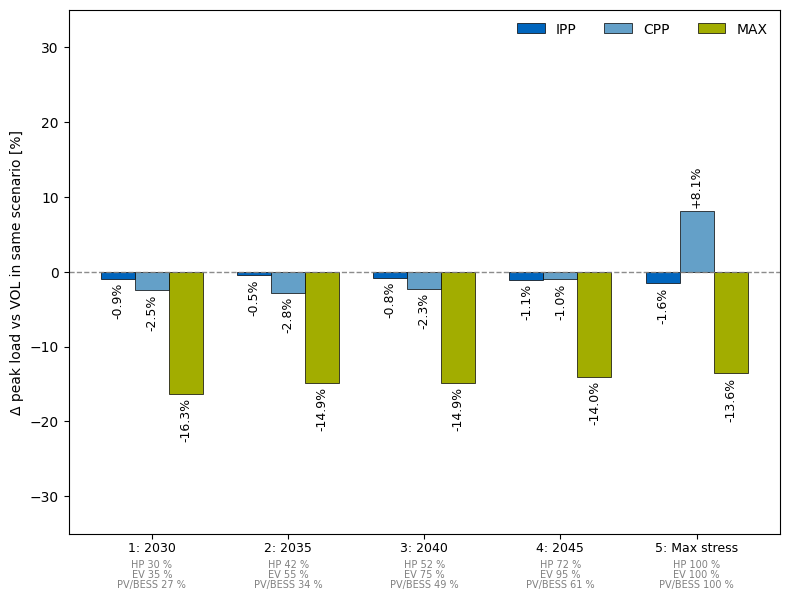

In [17]:
# Deviation within each scenario: VOL in that scenario is the baseline (0%)
# Bars show Δ% vs that scenario's VOL for IPP, CPP, MAX (VOL omitted)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
TARIFF_ORDER = ["IPP", "CPP", "MAX"]  # VOL removed from plotting order
# TARIFF_ORDER = ["IPP", "CPP"]  # VOL removed from plotting order

COLOR_MAP = {
    "IPP": "#0065BD",   # blue
    "CPP": "#64A0C8",   # light blue
    "MAX": "#A2AD00",   # green
}
BAR_WIDTH = 0.25
LABEL_FMT = "{:+.1f}%"

def short_label(s: str, mode: str = "prefix_plus_year") -> str:
    m = re.match(r'^\s*(\d+):\s*([^(]+)', str(s))
    if not m:
        return str(s).strip()
    idx, name = m.group(1), m.group(2).strip()
    lname = name.lower()
    if lname.startswith("base"):
        name = "Base"
    elif lname.startswith("max stress"):
        name = "Max stress"
    # name = name.replace("2024", "Today")
    return name if mode == "year_only" else f"{idx}: {name}"

def _numkey(s):
    m = re.match(r"^\s*(\d+)", str(s))
    return int(m.group(1)) if m else 10**9

# --- aggregate to system per (scenario, tariff) ---
df = results_df.copy()
df["tariff"] = df["tariff"].replace({"CPPP": "CPP"})  # normalize any typos

grp_cols = ["scenario", "grid", "tariff"]
avg = df.groupby(grp_cols, as_index=False)[["scenario_load_hh_only"]].mean()

if "total_households" in df.columns:
    hh = df.groupby(grp_cols, as_index=False)["total_households"].mean()
    avg = avg.merge(hh, on=grp_cols, how="left")

    def wavg(block, val="scenario_load_hh_only", w="total_households"):
        v, wv = block[val].to_numpy(), block[w].to_numpy()
        return np.nan if np.nansum(wv) == 0 else np.nansum(v * wv) / np.nansum(wv)

    sys = (
        avg.groupby(["scenario", "tariff"])
           .apply(lambda g: wavg(g))
           .reset_index(name="scenario_load_hh_only")
    )
else:
    sys = avg.groupby(["scenario", "tariff"], as_index=False)["scenario_load_hh_only"].mean()

# pivot to scenario × tariff (keep VOL for baseline computation)
pivot = sys.pivot(index="scenario", columns="tariff", values="scenario_load_hh_only")
for t in ["VOL", *TARIFF_ORDER]:
    if t not in pivot.columns:
        pivot[t] = np.nan

pivot = pivot[["VOL", *TARIFF_ORDER]]

# sort scenarios by numeric prefix
pivot = pivot.sort_index(key=lambda s: s.map(_numkey))

# --- compute deviation within each scenario vs that scenario's VOL ---
if "VOL" not in pivot.columns:
    raise ValueError("VOL column not found; cannot normalize per scenario.")
vol_ref = pivot["VOL"].replace(0, np.nan)
dev = (pivot.divide(vol_ref, axis=0) - 1.0) * 100.0   # VOL→0%, others ±%

# --- remove "Base" and "2024" scenario ---
keep_index = [
    idx for idx in dev.index
    if "base" not in str(idx).lower() and "2024" not in str(idx)
]
dev = dev.loc[keep_index]

# build display labels from remaining scenarios
scen_labels = [short_label(s, "prefix_plus_year") for s in dev.index]
scenario_keys = [lbl.split(":")[-1].strip() for lbl in scen_labels]

# --- adoption labels (EDIT to your actual values) ---
adoption_labels = {
    # "2024":      "HP 4 %\nEV 3 %\nPV/BESS 14 %",
    "2030":       "HP 30 %\nEV 35 %\nPV/BESS 27 %",
    "2035":       "HP 42 %\nEV 55 %\nPV/BESS 34 %",
    "2040":       "HP 52 %\nEV 75 %\nPV/BESS 49 %",
    "2045":       "HP 72 %\nEV 95 %\nPV/BESS 61 %",
    "Max stress": "HP 100 %\nEV 100 %\nPV/BESS 100 %",
}
adopt_text = [adoption_labels.get(k, "") for k in scenario_keys]

# --- plot grouped deviation bars (VOL skipped) ---
x = np.arange(len(scen_labels))
plt.figure(figsize=(max(8, len(scen_labels) * 1.3), 6))

for i, t in enumerate(TARIFF_ORDER):
    offsets = x + (i - (len(TARIFF_ORDER) - 1) / 2) * BAR_WIDTH
    vals = dev[t].to_numpy(dtype=float)

    bars = plt.bar(
        offsets, vals, width=BAR_WIDTH,
        label=t, color=COLOR_MAP.get(t, None),
        edgecolor="black", linewidth=0.5
    )

    # label placement (inside centered if bar tall enough)
    for xi, v in zip(offsets, vals):
        if np.isnan(v):
            continue

        y = v + (0.5 if v >= 0 else -0.5)
        va = "bottom" if v >= 0 else "top"
 
        plt.text(
            xi, y, LABEL_FMT.format(v),
            ha="center", va=va, rotation=90,
            fontsize=9, color="black"
        )

# zero line (VOL baseline)
plt.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.9)

# x ticks & adoption labels
plt.xticks(x, scen_labels, ha="center", fontsize=9)
plt.tick_params(axis='x', pad=2)

for xi, txt in zip(x, adopt_text):
    plt.text(
        xi, -0.05, txt,
        transform=plt.gca().get_xaxis_transform(),
        ha="center", va="top",
        fontsize=7, color="gray", linespacing=1.0
    )

# symmetric y-lims around zero with headroom
absmax = np.nanmax(np.abs(dev[TARIFF_ORDER].values))
# ylim = np.ceil((absmax + 10) / 10) * 9
ylim = 35
plt.ylim(-ylim, ylim)

plt.ylabel("Δ peak load vs VOL in same scenario [%]")
# plt.title("Peak load deviation by tariff within each scenario (VOL = 100%)")
plt.legend(ncol=3, frameon=False)
plt.subplots_adjust(bottom=0.35)
plt.tight_layout()
plt.show()


C:\Users\55485\AppData\Local\Temp\ipykernel_14400\148310831.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: wavg(g))


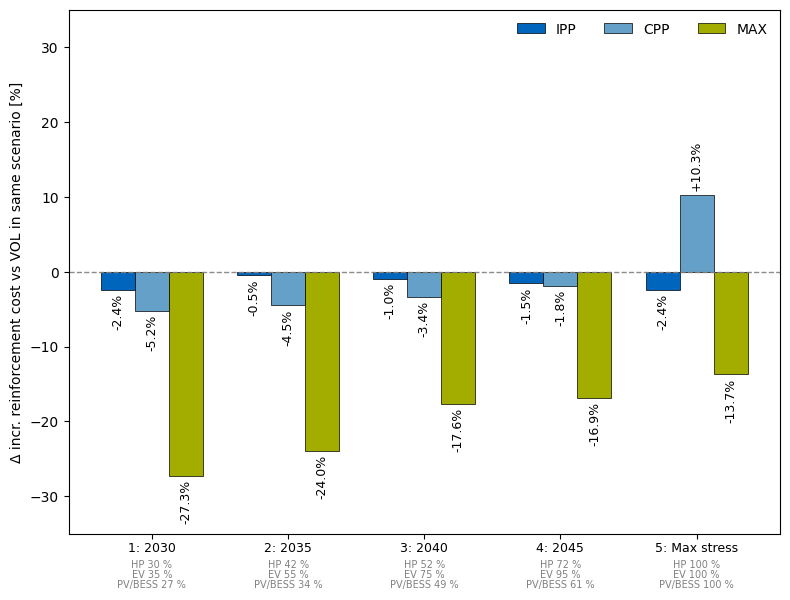

In [18]:
# Deviation within each scenario: VOL in that scenario is the baseline (0%)
# Bars show Δ% vs that scenario's VOL for IPP, CPP, MAX (VOL omitted)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
TARIFF_ORDER = ["IPP", "CPP", "MAX"]  # VOL removed from plotting order
# TARIFF_ORDER = ["IPP", "CPP"]  # VOL removed from plotting order
COLOR_MAP = {
    "IPP": "#0065BD",   # blue
    "CPP": "#64A0C8",   # light blue
    "MAX": "#A2AD00",   # green
}
BAR_WIDTH = 0.25
LABEL_FMT = "{:+.1f}%"

def short_label(s: str, mode: str = "prefix_plus_year") -> str:
    m = re.match(r'^\s*(\d+):\s*([^(]+)', str(s))
    if not m:
        return str(s).strip()
    idx, name = m.group(1), m.group(2).strip()
    lname = name.lower()
    if lname.startswith("base"):
        name = "Base"
    elif lname.startswith("max stress"):
        name = "Max stress"
    # name = name.replace("2024", "Today")
    return name if mode == "year_only" else f"{idx}: {name}"

def _numkey(s):
    m = re.match(r"^\s*(\d+)", str(s))
    return int(m.group(1)) if m else 10**9

# --- aggregate to system per (scenario, tariff) ---
df = results_df.copy()
df["tariff"] = df["tariff"].replace({"CPPP": "CPP"})  # normalize any typos

grp_cols = ["scenario", "grid", "tariff"]
avg = df.groupby(grp_cols, as_index=False)[["total_reinforcement_cost"]].mean()

if "total_households" in df.columns:
    hh = df.groupby(grp_cols, as_index=False)["total_households"].mean()
    avg = avg.merge(hh, on=grp_cols, how="left")

    def wavg(block, val="total_reinforcement_cost", w="total_households"):
        v, wv = block[val].to_numpy(), block[w].to_numpy()
        return np.nan if np.nansum(wv) == 0 else np.nansum(v * wv) / np.nansum(wv)

    sys = (
        avg.groupby(["scenario", "tariff"])
           .apply(lambda g: wavg(g))
           .reset_index(name="total_reinforcement_cost")
    )
else:
    sys = avg.groupby(["scenario", "tariff"], as_index=False)["total_reinforcement_cost"].mean()

# pivot to scenario × tariff (keep VOL for baseline computation)
pivot = sys.pivot(index="scenario", columns="tariff", values="total_reinforcement_cost")
for t in ["VOL", *TARIFF_ORDER]:
    if t not in pivot.columns:
        pivot[t] = np.nan

pivot = pivot[["VOL", *TARIFF_ORDER]]

# sort scenarios by numeric prefix
pivot = pivot.sort_index(key=lambda s: s.map(_numkey))

# --- compute deviation within each scenario vs that scenario's VOL ---
if "VOL" not in pivot.columns:
    raise ValueError("VOL column not found; cannot normalize per scenario.")
vol_ref = pivot["VOL"].replace(0, np.nan)
dev = (pivot.divide(vol_ref, axis=0) - 1.0) * 100.0   # VOL→0%, others ±%

# --- remove "Base" scenario ---
keep_index = [
    idx for idx in dev.index
    if "base" not in str(idx).lower() and "2024" not in str(idx)
]
dev = dev.loc[keep_index]

# build display labels from remaining scenarios
scen_labels = [short_label(s, "prefix_plus_year") for s in dev.index]
scenario_keys = [lbl.split(":")[-1].strip() for lbl in scen_labels]

# --- adoption labels (EDIT to your actual values) ---
adoption_labels = {
    # "2024":      "HP 4 %\nEV 3 %\nPV/BESS 14 %",
    "2030":       "HP 30 %\nEV 35 %\nPV/BESS 27 %",
    "2035":       "HP 42 %\nEV 55 %\nPV/BESS 34 %",
    "2040":       "HP 52 %\nEV 75 %\nPV/BESS 49 %",
    "2045":       "HP 72 %\nEV 95 %\nPV/BESS 61 %",
    "Max stress": "HP 100 %\nEV 100 %\nPV/BESS 100 %",
}
adopt_text = [adoption_labels.get(k, "") for k in scenario_keys]

# --- plot grouped deviation bars (VOL skipped) ---
x = np.arange(len(scen_labels))
plt.figure(figsize=(max(8, len(scen_labels) * 1.3), 6))

for i, t in enumerate(TARIFF_ORDER):
    offsets = x + (i - (len(TARIFF_ORDER) - 1) / 2) * BAR_WIDTH
    vals = dev[t].to_numpy(dtype=float)

    bars = plt.bar(
        offsets, vals, width=BAR_WIDTH,
        label=t, color=COLOR_MAP.get(t, None),
        edgecolor="black", linewidth=0.5
    )

    # label placement (inside centered if bar tall enough)
    for xi, v in zip(offsets, vals):
        if np.isnan(v):
            continue

        y = v + (0.5 if v >= 0 else -0.5)
        va = "bottom" if v >= 0 else "top"
 
        plt.text(
            xi, y, LABEL_FMT.format(v),
            ha="center", va=va, rotation=90,
            fontsize=9, color="black"
        )

# zero line (VOL baseline)
plt.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.9)

# x ticks & adoption labels
plt.xticks(x, scen_labels, ha="center", fontsize=9)
plt.tick_params(axis='x', pad=2)

for xi, txt in zip(x, adopt_text):
    plt.text(
        xi, -0.05, txt,
        transform=plt.gca().get_xaxis_transform(),
        ha="center", va="top",
        fontsize=7, color="gray", linespacing=1.0
    )

# symmetric y-lims around zero with headroom
absmax = np.nanmax(np.abs(dev[TARIFF_ORDER].values))
# ylim = np.ceil((absmax + 10) / 10) * 9
ylim = 35
plt.ylim(-ylim, ylim)

plt.ylabel("Δ incr. reinforcement cost vs VOL in same scenario [%]")
plt.legend(ncol=3, frameon=False)
plt.subplots_adjust(bottom=0.35)
plt.tight_layout()
plt.show()

# Equity

In [19]:
peak_times_equity = peak_times_main.copy()
hh_attribution_equity = hh_attribution_main.copy()

def classify_group(df):
    load_flag = (df["has_HP"] | df["has_EV"]).astype(int) * 2      # 0 or 2
    bess_flag = df["has_PV_BESS"].astype(int)                      # 0 or 1
    code = load_flag + bess_flag                                    # 0..3

    labels = {0: "Non-adopters",
              1: "PV-BESS only",
              2: "HP/ EV only",
              3: "HP/ EV + PV-BESS"}
    
    # labels = {0: "No PV/BESS",
    #           1: "PV/BESS",
    #           2: "No PV/BESS",
    #           3: "PV/BESS"}

    
    return pd.Series(code).map(labels).values

for d in [peak_times_equity, hh_attribution_equity]:
    d["group"] = classify_group(d)

peak_times_equity = peak_times_equity.groupby(["grid", "seed", "scenario", "tariff", "top_time_index", "group"], as_index=False).agg({
    "n_households": "sum",
    "hh_hp_ev_kW": "sum",
    "pv_kW": "sum",
    "bess_kW": "sum",
    "import_kW": "sum"
})

hh_attribution_equity = hh_attribution_equity.groupby(["grid","seed", "scenario", "tariff", "group"], as_index=False).agg({
    "n_households": "sum",
    "import_kWh": "sum",
    "window_peak_kW": "sum",
    "import_in_cpp_events_kWh": "sum"
})
reinforcement_equity = results_df[["grid", "seed", "scenario", "tariff", "total_reinforcement_cost"]]

In [32]:
# 1) group import at each peak time
gp_t = (peak_times_equity
        .groupby(["grid","seed","scenario","tariff","top_time_index","group"], as_index=False)
        .agg(n_households=("n_households", "sum"), 
             cpeak_group_import_kW=("import_kW","sum")))

# 2) system import at each peak time
sys_t = (peak_times_equity
         .groupby(["grid","seed","scenario","tariff","top_time_index"], as_index=False)
         .agg(cpeak_sys_import_kW=("import_kW","sum")))

# 3) per-time share, then mean of shares across the n peak times (Hennig-style)
peak_shares = gp_t.merge(sys_t, on=["grid","seed","scenario","tariff","top_time_index"])
peak_shares["cpeak_share_group"] = peak_shares["cpeak_group_import_kW"] / peak_shares["cpeak_sys_import_kW"]
peak_shares["cpeak_share_group_household"] = (peak_shares["cpeak_group_import_kW"] / peak_shares["n_households"]) / peak_shares["cpeak_sys_import_kW"]

peak_shares = (peak_shares
               .groupby(["grid","seed","scenario","tariff","group"], as_index=False)
               .agg(n_households=("n_households","mean"),
                    cpeak_share_group=("cpeak_share_group","mean"),
                    cpeak_share_group_household=("cpeak_share_group_household","mean")))

# peak_shares = peak_shares[peak_shares["top_time_index"]==1].drop(columns=["top_time_index"])  # focus on top time only


In [33]:
cpp_factor = 6
pay_shares = hh_attribution_equity.copy()
pay_shares = pay_shares.rename(
    columns={
        "import_kWh": "annual_import_kWh",
        "window_peak_kW": "individual_peak_kW"
    }
)
pay_shares["pay_base"] = np.select(
    [
        pay_shares["tariff"] == "VOL",
        pay_shares["tariff"] == "IPP",
        pay_shares["tariff"] == "CPP"
    ],
    [
        pay_shares["annual_import_kWh"],
        pay_shares["individual_peak_kW"],
        pay_shares["import_in_cpp_events_kWh"] * (cpp_factor - 1) + pay_shares["annual_import_kWh"],
    ],
    default=pay_shares["annual_import_kWh"]
)

pay_shares["total_pay"] = (pay_shares
    .groupby(["grid", "seed", "scenario", "tariff"])["pay_base"]
    .transform("sum"))

pay_shares["pay_share_group"] = pay_shares["pay_base"] / pay_shares["total_pay"]
pay_shares["pay_share_group_household"] = (pay_shares["pay_base"] / pay_shares["n_households"]) / pay_shares["total_pay"]


In [34]:
fairness_results = peak_shares.merge(pay_shares, on=["grid","seed","scenario","tariff","group", "n_households"], how="inner")
fairness_results["fairness"] = (fairness_results["pay_share_group_household"] - fairness_results["cpeak_share_group_household"])/fairness_results["pay_share_group_household"] * 100
fairness_results["n_households_grid"] = (fairness_results
    .groupby(["grid", "seed", "scenario", "tariff"])["n_households"]
    .transform("sum"))
fairness_results["fairness_weighted"] = (fairness_results["fairness"] * fairness_results["n_households"]) / fairness_results["n_households_grid"]
# fairness_results.to_excel("fairness_results.xlsx", index=False)
fairness_results = fairness_results.drop(columns=["cpeak_share_group", "cpeak_share_group_household", "pay_share_group", "pay_share_group_household", "pay_base", "total_pay"])
fairness_results_grouped = fairness_results.groupby(["scenario","tariff","group"], as_index=False).agg(
    n_households=("n_households", "mean"),
    fairness_mean=("fairness", "mean"),
    fairness_std=("fairness", "std")
)


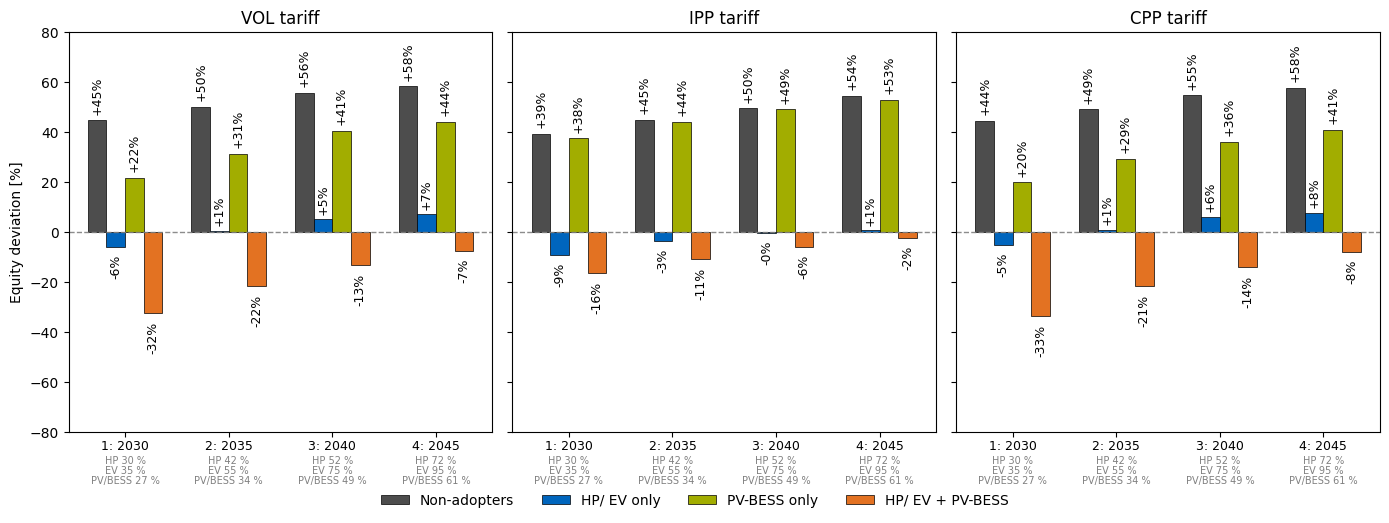

In [41]:
def short_label(s: str, mode: str = "prefix_plus_year") -> str:
    m = re.match(r'^\s*(\d+):\s*([^(]+)', str(s))
    if not m: 
        return str(s).strip()
    idx, name = m.group(1), m.group(2).strip()
    lname = name.lower()
    if lname.startswith("base"): name = "Base"
    elif lname.startswith("max stress"): name = "Max stress"
    # rename 2024 -> Today in the visible label
    name = name.replace("2024", "Today")
    return name if mode == "year_only" else f"{idx}: {name}"

def _numkey(s):
    m = re.match(r"^\s*(\d+)", str(s))
    return int(m.group(1)) if m else 10**9

# adoption text (used under x ticks)
adoption_labels = {
    # "Today":      "HP 4 %\nEV 3 %\nPV/BESS 14 %",
    "2030":       "HP 30 %\nEV 35 %\nPV/BESS 27 %",
    "2035":       "HP 42 %\nEV 55 %\nPV/BESS 34 %",
    "2040":       "HP 52 %\nEV 75 %\nPV/BESS 49 %",
    "2045":       "HP 72 %\nEV 95 %\nPV/BESS 61 %"
}

# ==== PREP ====
df = fairness_results_grouped.copy()

# drop "Base" and "Max stress" scenario rows
mask_keep = ~df["scenario"].str.lower().str.contains("base|max stress|2024")
df = df[mask_keep].copy()

# sort scenarios numerically by the prefix
df = df.sort_values("scenario", key=lambda s: s.map(_numkey))

# build display labels & keys for adoption text
df["scen_label"] = df["scenario"].apply(lambda s: short_label(s, "prefix_plus_year"))
df["scen_key"]   = df["scen_label"].str.split(":").str[-1].str.strip()

# tidy sets for iteration
tariffs = ["VOL", "IPP", "CPP"]
groups_order = ["Non-adopters", "HP/ EV only", "PV-BESS only", "HP/ EV + PV-BESS"]
group_colors = {
    "Non-adopters":     "#4D4D4D",
    "HP/ EV only":      "#0065BD",
    "PV-BESS only":     "#A2AD00",
    "HP/ EV + PV-BESS": "#E37222",
}

# groups_order = ["No PV/BESS", "PV/BESS"]
# group_colors = {
#     "No PV/BESS":  "#4D4D4D",
#     "PV/BESS":     "#0065BD",
# }

# consistent scenario order across panels
scenarios = df["scen_label"].unique().tolist()
x = np.arange(len(scenarios))
BAR_WIDTH = 0.18  # per group within a scenario

# ==== PLOT ====
fig, axes = plt.subplots(1, len(tariffs),  figsize=(14, 5), sharey=True)

for ax, t in zip(axes, tariffs):
    sub = df[df["tariff"] == t]

    # ensure every group × scenario is present (fill with NaN if not)
    grid_plot = (
        sub.set_index(["group","scen_label"])
           .reindex(pd.MultiIndex.from_product([groups_order, scenarios], names=["group","scen_label"]))
           .reset_index()
    )

    # grouped bars per scenario
    for i, g in enumerate(groups_order):
        vals = grid_plot.loc[grid_plot["group"]==g, "fairness_mean"].to_numpy(dtype=float)

        offsets = x + (i - (len(groups_order)-1)/2)*BAR_WIDTH
        bars = ax.bar(offsets, vals, width=BAR_WIDTH, color=group_colors[g], edgecolor="black", linewidth=0.5, label=g)

        # labels (small, above/below)
        for xi, v in zip(offsets, vals):
            if np.isnan(v): 
                continue
            if v>0:
                dy= 8
                if v>10:
                    dy = 10
                if v>100:
                    dy=20
            if v<=0:
                dy = -8
                if v< -10:
                    dy= -10
                if v< -100:
                    dy=-20
            va = "center" if v >= 0 else "center"
            ax.text(xi, v + dy, f"{v:+.0f}%", ha="center",rotation=90, va=va, fontsize=9)

    # zero line
    ax.axhline(0, linestyle="--", linewidth=1, color="gray", alpha=0.9)

    # x ticks for scenarios
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=0, fontsize=9)
    ax.tick_params(axis='x', pad=2)

    # adoption labels block under ticks
    keys = [lbl.split(":")[-1].strip() for lbl in scenarios]
    adopt_text = [adoption_labels.get(k, "") for k in keys]
    for xi, txt in zip(x, adopt_text):
        ax.text(xi, -0.06, txt, transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7, color="gray", linespacing=1.0)

    ax.set_title(f"{t} tariff")
    ax.set_xlabel("")

# y limits symmetric
absmax = np.nanmax(np.abs(df["fairness_mean"].values))
ylim = 80
axes[0].set_ylim(-ylim, ylim)
axes[0].set_ylabel("Equity deviation [%]")

# one legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(groups_order), loc="lower center", bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.subplots_adjust(bottom=0.28, top=0.88, wspace=0.25)
plt.tight_layout()
plt.show()
